# Checking concept spread types on unseen and medical data — evaluation demo

This notebook is a runnable walk-through of `eval.py`, the evaluation of the **frozen RQ2 descriptive layer**. That layer assigns each
research concept to one of two diffusion types with a frozen k=2 DTW-medoid typology:

* **BROAD** — "broad from the start (rapid interdisciplinary)"
* **LOCALISED**

The full evaluation has eight steps (`typology rooting mesh leadlag confirmation cases figures assemble`). Several of them need the
large frozen experiment tree, the sealed held-out corpus and the MeSH corpus, none of which fit in a demo. This notebook runs the
three analysis steps that work on concept- and entry-level tables, using the **original step code**:

1. **`typology_extras`** — how far each concept sits from the two frozen medoids (d1, d2, margin), out-of-support shares, a KS test of
   held-out vs screen distances, and permutation chi² cross-tabs of type × concept attributes with Holm correction.
2. **`rooting`** — type × occupancy / rooting on the D2 host entries (one row = a concept entering a host subfield `d` in year `e`):
   raw descriptives with concept-cluster bootstraps, host × entry-year fixed-effect regressions of host share (`A_cont`) and
   co-transfer (`CT`) on type, and the exploratory PPML interaction.
3. **`leadlag_table`** — the lead-lag denominator table (does *expansion* come before *diffusion*?), with Kaplan–Meier curves and a
   log-rank test for censoring.

**Data:** `mini_demo_data.json` holds 100 concepts (60 screen + 40 held-out, stratified by type). Each concept carries its stored
typology distances, lead-lag onsets and its D2 co-primary host entries. The held-out entries carry W1 features only; the W2 outcomes
stay sealed. Because this is a subset with reduced bootstrap and permutation counts, the numbers differ from the full run. The last
cell compares them with the full-run reference values stored in the same file.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# pyfixest (FE regressions), lifelines (Kaplan-Meier / log-rank), loguru (logging) — NOT on Colab, always install
_pip('pyfixest==0.60.0', 'lifelines==0.30.3', 'loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
from __future__ import annotations

# --- eval.py
import sys
import time
from pathlib import Path

from loguru import logger

# --- evalsteps/base.py
import hashlib
import json
import math
import os

import numpy as np
import pandas as pd

# --- evalsteps/typology_extras.py
from scipy.stats import ks_2samp

# --- notebook additions (PPML helper module stand-in, plotting)
import types
import matplotlib.pyplot as plt

## Load the demo data

The data comes from GitHub, with a local fallback so the notebook also runs next to `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-4/evaluation-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print("concepts:", data["metadata"]["n_concepts"], "| host entries:", data["metadata"]["n_entries"])

100 concepts (60 screen + 40 held-out MAIN) from the RQ2 evaluation, each with its frozen k=2 typology distances, lead-lag onsets and its D2 co-primary host entries (held-out: W1 features only, no outcomes).
concepts: 100 | host entries: 1044


## Configuration

These are all the tunable parameters. The bootstrap and permutation counts are at the **original** values; together they take
about a minute here. Each comment gives a quick-test value. These counts only change how precise the CIs and p-values are, not the
point estimates. The sample is the reduced part: 100 concepts instead of 302.
`N_SCREEN` / `N_HELDOUT` limit how many of the 100 demo concepts are used (at most 60 / 40).

In [5]:
# --- sample size (the demo file holds 60 screen + 40 held-out concepts; the full run used 202 + 100 concepts)
N_SCREEN = 60              # original: all 202 screen MAIN concepts (184 with D2 entries)
N_HELDOUT = 40             # original: all 100 held-out MAIN concepts (93 with D2 entries)

# --- typology_extras
N_PERM = 10000             # original: 10000 permutations for perm_chi2 (quick test: 99)
CRAMERS_V_B = 1000         # original: 1000 bootstrap draws for the Cramer's V CI (quick test: 20)
ENFORCE_SCREEN_GATE = False  # original: True. The gate checks that the full screen reproduces exp8's cross-tab p-values; a 60-concept subset cannot

# --- rooting
B_BOOT = 2000              # original: 2000 concept-cluster bootstrap draws (descriptives) (quick test: 20)
PPML_MAXIT = 500           # original: 500
PPML_TOL = 1e-12           # original: 1e-12

# --- leadlag_table
B_EF = 2000                # original: 2000 bootstrap draws for the expansion-first share CI (quick test: 20)

## `eval.py` driver: logging and step list

`eval.py` is a thin dispatcher: it sets up loguru and imports each step module from `evalsteps/`, then calls its `run()`. In the
notebook the step functions are defined in the cells below and called directly. The file log sink (`logs/eval.log`) is left out.

In [6]:
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

STEPS = ["typology", "rooting", "mesh", "leadlag", "confirmation", "cases", "figures", "assemble"]
DEMO_STEPS = ["typology", "rooting", "leadlag"]  # the steps that run self-contained on mini_demo_data.json

## Shared helpers (`evalsteps/base.py`)

These are copied unchanged: type labels, JSON cleaning, Wilson and Newcombe intervals, the concept-cluster bootstrap, Holm
correction, and the bootstrap CI for Cramér's V. The only change is the paths. The frozen experiment tree (`E7`, `E8`, `HO`) is
replaced by the `data` object, and `results/` is a local folder.

In [7]:
RES = Path("results")
RES.mkdir(exist_ok=True)

BROAD = "broad from the start (rapid interdisciplinary)"
LOCAL = "localised"
TYPE_SHORT = {BROAD: "BROAD", LOCAL: "LOCALISED"}
Z = 1.959964


def sha256(p: Path) -> str:
    return hashlib.sha256(Path(p).read_bytes()).hexdigest()


def clean(o):
    if isinstance(o, dict):
        return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        v = float(o)
        return None if not math.isfinite(v) else v
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return clean(o.tolist())
    if o is pd.NA or o is pd.NaT:
        return None
    return o


def write_json(p: Path, obj) -> None:
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(json.dumps(clean(obj), indent=1, default=str))


def wilson(k: int, n: int) -> list:
    if n == 0:
        return [None, None]
    p = k / n
    den = 1 + Z * Z / n
    c = (p + Z * Z / (2 * n)) / den
    h = Z * math.sqrt(p * (1 - p) / n + Z * Z / (4 * n * n)) / den
    return [max(0.0, c - h), min(1.0, c + h)]


def newcombe(k1: int, n1: int, k2: int, n2: int) -> dict:
    """Newcombe hybrid-score CI for p1 - p2."""
    if n1 == 0 or n2 == 0:
        return dict(diff=None, ci=[None, None])
    p1, p2 = k1 / n1, k2 / n2
    l1, u1 = wilson(k1, n1)
    l2, u2 = wilson(k2, n2)
    d = p1 - p2
    lo = d - math.sqrt((p1 - l1) ** 2 + (u2 - p2) ** 2)
    hi = d + math.sqrt((u1 - p1) ** 2 + (p2 - l2) ** 2)
    return dict(diff=d, ci=[lo, hi])


def share(k: int, n: int) -> dict:
    return dict(k=int(k), n=int(n), share=(k / n) if n else None, wilson_ci=wilson(int(k), int(n)))


def cluster_boot_many(df: pd.DataFrame, stats: dict, cluster: str = "concept_id", B: int = 2000, seed: int = 0) -> dict:
    """Same resamples for several statistics (faster, index-based)."""
    codes, uniq = pd.factorize(df[cluster])
    idx_by = [np.flatnonzero(codes == i) for i in range(len(uniq))]
    rng = np.random.default_rng(seed)
    obs = {k: f(df) for k, f in stats.items()}
    draws = {k: [] for k in stats}
    for _ in range(B):
        pick = rng.integers(0, len(uniq), len(uniq))
        rows = np.concatenate([idx_by[i] for i in pick])
        d = df.iloc[rows]
        for k, f in stats.items():
            v = f(d)
            if v is not None and np.isfinite(v):
                draws[k].append(v)
    return {k: dict(est=obs[k], ci=(np.percentile(draws[k], [2.5, 97.5]).tolist() if draws[k] else [None, None]),
                    B=B, n_clusters=len(uniq), n_rows=len(df)) for k in stats}


def holm(pvals: dict) -> dict:
    items = [(k, v) for k, v in pvals.items() if v is not None and np.isfinite(v)]
    items.sort(key=lambda kv: kv[1])
    m, out, run = len(items), {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        out[k] = run
    return out


def cramers_v_boot(a: pd.Series, b: pd.Series, B: int = 1000, seed: int = 0) -> list:
    m = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    ai = pd.factorize(m.a.astype(str), sort=True)[0]
    bi = pd.factorize(m.b.astype(str), sort=True)[0]
    rng = np.random.default_rng(seed)
    vs = []
    for _ in range(B):
        ix = rng.integers(0, len(m), len(m))
        x, y = ai[ix], bi[ix]
        ka, kb = len(set(x)), len(set(y))
        if ka < 2 or kb < 2:
            continue
        tab = pd.crosstab(x, y).to_numpy().astype(float)
        e = tab.sum(1, keepdims=True) * tab.sum(0, keepdims=True) / tab.sum()
        chi = ((tab - e) ** 2 / e).sum()
        vs.append(math.sqrt(chi / (tab.sum() * (min(tab.shape) - 1))))
    return np.percentile(vs, [2.5, 97.5]).tolist() if vs else [None, None]

## Rebuild the input tables from `data`

The original steps read parquet and CSV files from the frozen experiment tree. Here the same tables are rebuilt from the JSON:

* `typ_s`, `typ_h` — one row per concept, like `typology/assignments.csv` and `results/typology_distances.csv`: cluster, `dtw_to_<medoid>`
  distances and the cross-tab variables.
* `ev_s`, `ev_h` — one row per D2 host entry, like `rooting_screen_sample.parquet` and `rooting_heldout_sample_W1.parquet`: host share
  `A_cont`, co-transfer `CT`, controls and (screen only) the outcomes `Y_strict` / `EST_bin`.
* `ll_s`, `ll_h` — one row per concept, like `leadlag_by_concept.csv`: expansion / diffusion onset years and the lead-lag category.
* `F_all` — each concept's first year `F`.

In [8]:
MEDO = dict(medoid_ids=data["metadata"]["medoid_ids"], cluster_names=data["metadata"]["cluster_names"])

ex_s = [x for x in data["examples"] if x["population"] == "screen"][:N_SCREEN]
ex_h = [x for x in data["examples"] if x["population"] == "heldout"][:N_HELDOUT]

def _concepts(ex):
    return pd.DataFrame([dict(concept_id=x["concept_id"], **x["typology"]) for x in ex])

def _entries(ex):
    return pd.DataFrame([dict(concept_id=x["concept_id"], **r) for x in ex for r in x["host_entries"]])

def _leadlag(ex):
    return pd.DataFrame([dict(concept_id=x["concept_id"], cluster_name=x["typology"]["cluster_name"],
                              origin_group=x["typology"]["origin_group"], **x["leadlag"]) for x in ex])

typ_s, typ_h = _concepts(ex_s), _concepts(ex_h)
ev_s, ev_h = _entries(ex_s), _entries(ex_h)
ll_s, ll_h = _leadlag(ex_s), _leadlag(ex_h)
F_all = pd.Series({x["concept_id"]: x["F"] for x in ex_s + ex_h}, name="F")
for nm, df in [("typ_s", typ_s), ("typ_h", typ_h), ("ev_s", ev_s), ("ev_h", ev_h), ("ll_s", ll_s), ("ll_h", ll_h)]:
    print(f"{nm:6s} {df.shape}")
ev_s.head(3)

typ_s  (60, 13)
typ_h  (40, 13)
ev_s   (538, 26)
ev_h   (506, 24)
ll_s   (60, 10)
ll_h   (40, 10)


,concept_id,arm,fold,MAIN,kw5,d,e,n_entry_papers,A_cont,A0_cont,...,cov,demic,mean_topic_score,boundary_share,abstract_share,mom_d,log_centrality,log_W1,Y_strict,EST_bin
0,c_007a7950eb4d,main,screen,True,True,3109,2007,1,0.020494,0.032367,...,1.000000,0.0,0.9664,0.0,1.0,0.204735,2.772589,1.386294,0,0
1,c_007a7950eb4d,main,screen,True,True,1707,2008,1,0.030213,0.123576,...,0.571429,0.0,0.9821,0.0,1.0,0.170293,4.007333,2.484907,0,0
2,c_007a7950eb4d,main,screen,True,True,1803,2008,1,0.018600,0.042932,...,1.000000,0.0,0.9988,1.0,0.0,0.266457,4.007333,2.484907,3,0


## Step 1 — `typology_extras`: distances, support and cross-tabs

**Distances and margin.** For each concept, `d1` is the DTW distance to the nearest frozen medoid and `d2` the distance to the other
one. `margin = (d2 - d1) / (d2 + d1)` measures how clearly the concept belongs to its type; a margin below 0.05 counts as
*ambiguous*. A held-out concept is *out of support* if its `d1` exceeds the screen's 95th percentile. A KS test then compares the
held-out `d1` distribution with the screen one.

**Cross-tabs.** `perm_chi2` is copied verbatim from the frozen `exp8_frozen/src/typology.py`. It gives a permutation chi² test of
type × {E_up group, closure tercile, F band, origin field}, with Holm correction over those 4 variables and `route` as a null check.

`assign_series` (re-assigning concepts by DTW from raw indicator series) is not included. It needs the frozen indicator panel and DTW
code, so the demo uses the stored `dtw_to_<medoid>` distances. This is the same path the original takes for the held-out fold
(`add_margin` on stored assignments).

In [9]:
# ---- verbatim from exp8_frozen/src/typology.py (frozen code imported by typology_extras.crosstabs)
def perm_chi2(a: pd.Series, b: pd.Series, n_perm: int = 10000, seed: int = 0) -> dict:
    m = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    ai = pd.factorize(m.a.astype(str), sort=True)
    bi = pd.factorize(m.b.astype(str), sort=True)
    ka, kb, n = len(ai[1]), len(bi[1]), len(m)
    if ka < 2 or kb < 2:
        return dict(n=n, chi2=np.nan, p_perm=np.nan)

    def chi2(x, y):
        tab = np.bincount(x * kb + y, minlength=ka * kb).reshape(ka, kb).astype(float)
        e = tab.sum(1, keepdims=True) * tab.sum(0, keepdims=True) / n
        return float(((tab - e) ** 2 / np.where(e > 0, e, 1)).sum()), tab, e

    obs, tab, e = chi2(ai[0], bi[0])
    rng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        if chi2(ai[0], rng.permutation(bi[0]))[0] >= obs - 1e-12:
            ge += 1
    rs = (tab - e) / np.sqrt(np.where(e > 0, e, 1) * (1 - tab.sum(1, keepdims=True) / n) * (1 - tab.sum(0, keepdims=True) / n))
    V = math.sqrt(obs / (n * (min(ka, kb) - 1)))
    return dict(n=n, chi2=obs, p_perm=(ge + 1) / (n_perm + 1), cramers_v=V, rows=list(ai[1]), cols=list(bi[1]),
                table=tab.astype(int).tolist(), std_residuals=np.round(rs, 3).tolist(), min_expected=float(e.min()))

In [10]:
# ---- evalsteps/typology_extras.py (unchanged apart from the n_perm / B config variables)
def add_margin(a: pd.DataFrame) -> pd.DataFrame:
    cols = [f"dtw_to_{m}" for m in MEDO["medoid_ids"]]
    D = a[cols].to_numpy(float)
    a = a.copy()
    a["d1"] = D.min(axis=1)
    a["d2"] = D.max(axis=1)
    a["margin"] = (a.d2 - a.d1) / (a.d2 + a.d1)
    return a


def dist_summary(a: pd.DataFrame, screen_d1_p95: float, screen_d1: np.ndarray | None = None) -> dict:
    n = len(a)
    amb = int((a.margin < 0.05).sum())
    oos = int((a.d1 > screen_d1_p95).sum())
    out = dict(n=n, d1_median=float(a.d1.median()), d1_iqr=[float(a.d1.quantile(0.25)), float(a.d1.quantile(0.75))],
               margin_median=float(a.margin.median()), margin_iqr=[float(a.margin.quantile(0.25)), float(a.margin.quantile(0.75))],
               ambiguous_margin_lt_0_05=share(amb, n), out_of_support_d1_gt_screen_p95=share(oos, n),
               by_type={t: dict(n=int(len(g)), d1_median=float(g.d1.median()), margin_median=float(g.margin.median()))
                        for t, g in a.groupby("cluster_name")})
    if screen_d1 is not None:
        ks = ks_2samp(a.d1.values, screen_d1)
        out["ks_vs_screen_d1"] = dict(stat=float(ks.statistic), p=float(ks.pvalue))
    return out


def crosstabs(a: pd.DataFrame, vars_: list[str], check: str | None = "route", n_perm: int = 10000) -> dict:
    res = {}
    for v in vars_ + ([check] if check else []):
        if v not in a.columns or a[v].notna().sum() < 5:
            res[v] = dict(n=0, note="not available")
            continue
        r = perm_chi2(a.cluster.astype(str), a[v].astype(str).where(a[v].notna()), n_perm=n_perm, seed=0)
        if np.isfinite(r.get("chi2", np.nan)):
            r["cramers_v_boot_ci"] = cramers_v_boot(a.cluster, a[v].where(a[v].notna()), B=CRAMERS_V_B)
        res[v] = r
    ph = holm({v: res[v].get("p_perm") for v in vars_ if res[v].get("p_perm") is not None})
    for v in vars_:
        res[v]["p_holm"] = ph.get(v)
    return res


def type_shares(a: pd.DataFrame) -> dict:
    n = len(a)
    return {t: share(int((a.cluster_name == t).sum()), n) for t in (BROAD, LOCAL)}

`run_typology()` follows `typology_extras.run()`. The screen frame uses the frozen cluster labels. The screen cross-tabs are then
checked against the exp8 p-values (the "gate"); in the original, the held-out and pooled cross-tabs are withheld if that gate fails.
A 60-concept subset cannot reproduce full-sample p-values, so the gate is still computed and reported, but by default
(`ENFORCE_SCREEN_GATE = False`) it does not block the held-out and pooled cross-tabs.

In [11]:
def run_typology() -> dict:
    # screen: stored frozen assignments + distances (replaces assign_series + merge with assignments.csv)
    scr = add_margin(typ_s)
    p95 = float(scr.d1.quantile(0.95))
    out = dict(screen=dict(n=len(scr), type_shares=type_shares(scr), distances=dist_summary(scr, p95), d1_p95=p95))
    CT_VARS = ["E_up_group", "closure_tercile", "F_band", "origin_group"]
    ct_s = crosstabs(scr, CT_VARS, n_perm=N_PERM)
    target = dict(E_up_group=0.097, closure_tercile=0.11, F_band=0.077, origin_group=0.004)
    gate = {v: dict(got=round(ct_s[v]["p_perm"], 3), want=target[v], ok=abs(round(ct_s[v]["p_perm"], 2) - round(target[v], 2)) < 1e-9 or abs(ct_s[v]["p_perm"] - target[v]) < 0.006)
            for v in CT_VARS}
    out["screen"]["crosstabs"] = ct_s
    out["screen_crosstab_gate"] = dict(by_var=gate, passed=all(g["ok"] for g in gate.values()))
    logger.info(f"screen cross-tab gate {out['screen_crosstab_gate']}")
    frames = {"screen": scr}
    ho = add_margin(typ_h)
    frames["heldout"] = ho
    out["heldout"] = dict(n=len(ho), type_shares=type_shares(ho), distances=dist_summary(ho, p95, scr.d1.values))
    if out["screen_crosstab_gate"]["passed"] or not ENFORCE_SCREEN_GATE:
        out["heldout"]["crosstabs"] = crosstabs(ho, CT_VARS, n_perm=N_PERM)
        pool = pd.concat([scr.assign(population="screen"), ho.assign(population="heldout")], ignore_index=True)
        frames["pooled"] = pool
        out["pooled"] = dict(n=len(pool), type_shares=type_shares(pool), crosstabs=crosstabs(pool, CT_VARS, n_perm=N_PERM))
    else:
        out["heldout"]["crosstabs"] = "withheld: screen reproduction gate failed"
    cols = ["concept_id", "cluster", "cluster_name", "d1", "d2", "margin"] + [f"dtw_to_{m}" for m in MEDO["medoid_ids"]] + CT_VARS + ["route"]
    pd.concat([f.assign(population=k)[[c for c in cols if c in f.columns] + ["population"]] for k, f in frames.items() if k != "pooled"],
              ignore_index=True).to_csv(RES / "typology_distances.csv", index=False)
    write_json(RES / "typology_extras.json", out)
    return out


t0 = time.time()
logger.info("=== step typology")
typ_out = run_typology()
logger.info(f"=== step typology done in {time.time() - t0:.0f}s")
for pop in ("screen", "heldout"):
    ds = typ_out[pop]["distances"]
    print(f"{pop:8s} n={ds['n']:3d}  BROAD share={typ_out[pop]['type_shares'][BROAD]['share']:.2f}  median d1={ds['d1_median']:.3f}  "
          f"median margin={ds['margin_median']:.3f}  ambiguous={ds['ambiguous_margin_lt_0_05']['share']:.2f}  "
          f"out-of-support={ds['out_of_support_d1_gt_screen_p95']['share']:.2f}")
print("KS held-out vs screen d1: p =", round(typ_out["heldout"]["distances"]["ks_vs_screen_d1"]["p"], 3))

21:08:30|INFO   |=== step typology


21:08:41|INFO   |screen cross-tab gate {'by_var': {'E_up_group': {'got': 0.704, 'want': 0.097, 'ok': False}, 'closure_tercile': {'got': 0.839, 'want': 0.11, 'ok': False}, 'F_band': {'got': 0.087, 'want': 0.077, 'ok': False}, 'origin_group': {'got': 0.429, 'want': 0.004, 'ok': False}}, 'passed': False}


21:09:02|INFO   |=== step typology done in 32s


screen   n= 60  BROAD share=0.35  median d1=0.778  median margin=0.416  ambiguous=0.05  out-of-support=0.05
heldout  n= 40  BROAD share=0.38  median d1=0.832  median margin=0.399  ambiguous=0.05  out-of-support=0.07
KS held-out vs screen d1: p = 0.875


## Step 2 — `rooting`: type × occupancy and rooting on D2 host entries

Each row is one **host entry**: concept *c* enters host subfield *d* in year *e*. The main variables are:

* `A_cont` — host share: how much of the entry's partner vocabulary is native to the host. `A0_cont` is its baseline.
* `CT` — co-transfer: the share of partners the concept brings with it from its origin (a "package" import).
* `EST_bin`, `Y_strict` — whether, and how strongly, the concept roots in the host in window W2. These are screen only; held-out W2
  stays sealed.

The functions are copied from `evalsteps/rooting.py` with these changes:

* `B` comes from the config.
* The held-out loader keeps its "no outcome columns" assertion but drops the sha256 file check, since the data is read from JSON.
* `descriptives()` gets the co-primary sample as its `all_main` argument, because the wider all-MAIN entry table is not in the demo
  data. This affects only the occupancy line.
* `role_host_share` is not included, because it needs the per-year role panel.

The PPML helper `ppml.fit` is copied verbatim from the D2 experiment (`gen_art_experiment_7/src/ppml.py`). It is two-way FE Poisson
fitted by IRLS with sparse projections and CRV1 standard errors.

In [12]:
# ---- verbatim from gen_art_experiment_7/src/ppml.py (imported as `ppml` by rooting.ppml_interaction)
def _prune(y: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Iteratively drop singleton FE levels and FE levels with all-zero outcome (separation)."""
    keep = np.ones(len(y), bool)
    for _ in range(50):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            sy = np.bincount(f[keep], weights=y[keep], minlength=f.max() + 1)
            bad = (cnt <= 1) | (sy <= 0)
            drop = keep & bad[f]
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def _demean(M: np.ndarray, w: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Exact weighted projection off the FE space: solve (D'WD + eps I) c = D'W M with a sparse LU (D = [D1 D2])."""
    from scipy import sparse
    from scipy.sparse.linalg import splu
    n = len(w)
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    D = sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))
    DW = sparse.csc_matrix(D.multiply(w[:, None]))
    A = sparse.csc_matrix(D.T @ DW) + sparse.identity(off, format="csc") * 1e-9
    c = splu(A).solve(np.asarray(DW.T @ M))
    return M - D @ c


def pd_nunique_per_level(f: np.ndarray, g: np.ndarray) -> int:
    """Max number of distinct clusters within any FE level."""
    pairs = np.unique(np.stack([f, g], 1), axis=0)
    return int(np.bincount(pairs[:, 0]).max())


def fit(y: np.ndarray, X: np.ndarray, fes: list[np.ndarray], offset: np.ndarray, cluster: np.ndarray,
        maxit: int = 100, tol: float = 1e-9) -> dict | None:
    keep = _prune(y.astype(float), fes)
    if keep.sum() < X.shape[1] + 5:
        return None
    y, X, off, cl = y[keep].astype(float), X[keep], offset[keep], cluster[keep]
    fes = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    if np.linalg.matrix_rank(_demean(X, np.ones(len(y)), fes)) < X.shape[1]:
        return None
    mu = np.maximum(y, 0.1 * y.mean() + 1e-3)
    eta = np.log(mu)
    beta = np.zeros(X.shape[1])
    dev_old = np.inf
    for _ in range(maxit):
        z = eta - off + (y - mu) / mu
        M = _demean(np.column_stack([z, X]), mu, fes)
        zt, Xt = M[:, 0], M[:, 1:]
        WX = Xt * mu[:, None]
        beta = np.linalg.solve(Xt.T @ WX, WX.T @ zt)
        resid = zt - Xt @ beta
        eta = z - resid + off  # eta = X b + FE + offset
        eta = np.clip(eta, -30, 30)
        mu = np.exp(eta)
        dev = 2 * np.sum(np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))
        if abs(dev - dev_old) / (abs(dev) + 0.1) < tol:
            break
        dev_old = dev
    Xt = _demean(X, mu, fes)
    H = Xt.T @ (Xt * mu[:, None])
    Hi = np.linalg.inv(H)
    sc = Xt * (y - mu)[:, None]
    _, g = np.unique(cl, return_inverse=True)
    G = g.max() + 1
    S = np.zeros((G, X.shape[1]))
    np.add.at(S, g, sc)
    n = len(y)
    # small-sample factor as pyfixest CRV1 (fixef_k='nested'): FE levels nested in clusters are not counted
    k_fe = 0
    for f in fes:
        nested = np.all(np.bincount(f, minlength=f.max() + 1) == 0) or (
            pd_nunique_per_level(f, g) <= 1)
        if not nested:
            k_fe += int(f.max()) + 1 - 1
    k = X.shape[1] + k_fe + (1 if k_fe else 0)
    adj = G / (G - 1) * (n - 1) / (n - k) if G > 1 and n > k else 1.0
    V = adj * Hi @ (S.T @ S) @ Hi
    return {"coef": beta, "se": np.sqrt(np.diag(V)), "n": int(n), "G": int(G), "mu": mu, "keep": keep,
            "Xt": Xt, "y": y, "cl": g}


ppml = types.SimpleNamespace(fit=fit)  # stands in for `import ppml`

In [13]:
# ---- evalsteps/rooting.py
CTRL_EVENT = ["prox_od", "RD", "log_n_partner_tags", "cov", "demic", "mean_topic_score", "boundary_share", "abstract_share"]
CTRL_SEC = ["mom_d", "log_centrality", "log_W1"]
FORBIDDEN = ("Y_", "EST", "n_w2", "w2_", "present_")


def d2_sample(df: pd.DataFrame, fold: str) -> pd.DataFrame:
    s = df[(df.arm == "main") & (df.fold == fold) & df.kw5 & df.MAIN].copy()
    need = ["A_cont", "CT"] + CTRL_EVENT + CTRL_SEC
    return s.dropna(subset=[c for c in need if c in s.columns]).reset_index(drop=True)


def load_heldout_w1() -> pd.DataFrame:
    # original: sha256 check of sealed/heldout_features.parquet, then read it; here the W1 entries come from the JSON
    h = ev_h.copy()
    bad = [c for c in h.columns if c.startswith(FORBIDDEN)]
    assert not bad, f"outcome/W2 columns present in held-out features: {bad}"
    return h


def descriptives(s: pd.DataFrame, all_main: pd.DataFrame, with_outcomes: bool, B: int = 2000) -> dict:
    out = {}
    for t, g in s.groupby("type"):
        stats = {"A_cont_mean": lambda d: d.A_cont.mean(), "A_cont_concept_avg": lambda d: d.groupby("concept_id").A_cont.mean().mean(),
                 "excess_A": lambda d: (d.A_cont - d.A0_cont).mean(), "CT_mean": lambda d: d.CT.mean(),
                 "anchored_share": lambda d: d.anchored.astype(float).mean() if d.anchored.notna().any() else np.nan}
        if with_outcomes:
            stats.update({"Y_strict_mean": lambda d: d.Y_strict.mean(), "Y_pos_share": lambda d: (d.Y_strict > 0).mean(),
                          "EST_rate": lambda d: d.EST_bin.mean(), "rooted_share": lambda d: d.groupby("concept_id").EST_bin.mean().mean()})
        b = cluster_boot_many(g, stats, B=B, seed=1)
        b["A_cont_median"] = float(g.A_cont.median())
        b["n_entries"] = len(g)
        b["n_concepts"] = int(g.concept_id.nunique())
        out[t] = b
    # occupancy: entries per concept, all MAIN kw-any entries and co-primary sample (concepts with 0 entries included)
    occ = {}
    for t in ("BROAD", "LOCALISED"):
        a = all_main[all_main.type == t]
        occ[t] = dict(all_main_entries_per_concept=float(a.groupby("concept_id").size().mean()) if len(a) else None,
                      coprimary_entries_per_concept=float(s[s.type == t].groupby("concept_id").size().mean()) if (s.type == t).any() else None)
    out["occupancy"] = occ
    # type difference (BROAD - LOCALISED) by concept-cluster bootstrap, stratified by type
    diffs = {}
    keys = ["A_cont", "CT"] + (["Y_strict", "EST_bin"] if with_outcomes else [])
    rng = np.random.default_rng(7)
    gb = {t: {c: g for c, g in s[s.type == t].groupby("concept_id")} for t in ("BROAD", "LOCALISED")}
    obs = {k: s[s.type == "BROAD"][k].mean() - s[s.type == "LOCALISED"][k].mean() for k in keys}
    draws = {k: [] for k in keys}
    for _ in range(B):
        m = {}
        for t in ("BROAD", "LOCALISED"):
            cs = list(gb[t])
            pick = rng.integers(0, len(cs), len(cs))
            m[t] = pd.concat([gb[t][cs[i]] for i in pick])
        for k in keys:
            draws[k].append(m["BROAD"][k].mean() - m["LOCALISED"][k].mean())
    for k in keys:
        diffs[k] = dict(diff=obs[k], ci=np.percentile(draws[k], [2.5, 97.5]).tolist())
    out["diff_BROAD_minus_LOCALISED"] = diffs
    return out


def feols(s: pd.DataFrame, y: str) -> dict:
    import pyfixest as pf
    d = s.copy()
    d["BROAD"] = (d.type == "BROAD").astype(float)
    d["dxe"] = d.d.astype(str) + "_" + d.e.astype(str)
    extra = " + C(fold)" if d.fold.nunique() > 1 else ""
    f = pf.feols(f"{y} ~ BROAD + log_n_partner_tags + RD{extra} | dxe", data=d, vcov={"CRV1": "concept_id"})
    t = f.tidy()
    r = t.loc["BROAD"]
    return dict(y=y, n=int(f._N), n_concepts=int(d.concept_id.nunique()), coef=float(r["Estimate"]), se=float(r["Std. Error"]),
                p=float(r["Pr(>|t|)"]), ci=[float(r["2.5%"]), float(r["97.5%"])], sd_y=float(d[y].std()),
                coef_in_sd=float(r["Estimate"]) / float(d[y].std()), fe="host x entry year (d x e)", cluster="concept")


def ppml_interaction(s: pd.DataFrame) -> dict:
    # original: sys.path.insert(0, str(E7 / "src")); import ppml  -> `ppml` is defined in the cell above
    d = s.copy()
    d["BROAD"] = (d.type == "BROAD").astype(float)
    sdA = d.A_cont.std()
    d["A_x_BROAD"] = d.A_cont * d.BROAD
    xv = ["A_cont", "A_x_BROAD", "CT"] + CTRL_EVENT + CTRL_SEC
    fes = [pd.factorize(d.concept_id)[0], pd.factorize(d.e.astype(str))[0], pd.factorize(d.d.astype(str))[0]]
    off = np.log(d.n_entry_papers.astype(float).to_numpy())
    r = ppml.fit(d.Y_strict.to_numpy(float), d[xv].to_numpy(float), fes, off, d.concept_id.to_numpy(), maxit=PPML_MAXIT, tol=PPML_TOL)
    d["A_x_LOCAL"] = d.A_cont * (1 - d.BROAD)
    xv2 = ["A_x_LOCAL", "A_x_BROAD", "CT"] + CTRL_EVENT + CTRL_SEC
    r2 = ppml.fit(d.Y_strict.to_numpy(float), d[xv2].to_numpy(float), fes, off, d.concept_id.to_numpy(), maxit=PPML_MAXIT, tol=PPML_TOL)
    if r is None or r2 is None:
        return dict(note="PPML did not converge")
    from scipy.stats import norm
    bi, sei = float(r["coef"][1]), float(r["se"][1])
    irr = lambda bb, se: dict(coef=float(bb), se=float(se), irr_per_sd=float(np.exp(bb * sdA)),
                              ci=[float(np.exp((bb - 1.96 * se) * sdA)), float(np.exp((bb + 1.96 * se) * sdA))],
                              p=float(2 * norm.sf(abs(bb / se))))
    return dict(n_retained=int(r["n"]), G=int(r["G"]), sd_A_cont=float(sdA), LOCALISED=irr(r2["coef"][0], r2["se"][0]),
                BROAD=irr(r2["coef"][1], r2["se"][1]), interaction_coef=bi, interaction_se=sei,
                interaction_p=float(2 * norm.sf(abs(bi / sei))), fe="concept + e + host (D2 co-primary)",
                note="exploratory; type main effect absorbed by concept FE")

`run_rooting()` follows `rooting.run()`:

* **Screen.** Descriptives with outcomes; FE model (i), `A_cont ~ BROAD` with host × entry-year FE; FE model (ii), `CT ~ BROAD`;
  PPML (iii) `Y_strict ~ A_cont × type`; and the EST rate by `A_cont` quintile × type.
* **Held-out W1.** Descriptives without outcomes, and models (i) and (ii). It then checks the declared prediction
  "BROAD higher A_cont".
* **Pooled W1.** Models (i) and (ii) with a fold dummy.

In the original, `type` is joined from the frozen assignments. The demo entries already carry it.

In [14]:
def run_rooting() -> dict:
    ev = ev_s.copy()  # original: screen_events_with_outcomes.parquet + graft labels + frozen type
    all_main_s = ev[(ev.arm == "main") & (ev.fold == "screen") & ev.MAIN & ev.type.notna()]
    s = d2_sample(ev, "screen")
    s = s[s.type.notna()].reset_index(drop=True)
    out = dict(screen=dict(label="descriptive (screened data)", n_entries=len(s),
               n_concepts=int(s.concept_id.nunique()), n_unmatched_concepts=int(d2_sample(ev, "screen").type.isna().sum())))
    out["screen"]["descriptives"] = descriptives(s, all_main_s, True, B=B_BOOT)
    out["screen"]["model_i_Acont"] = feols(s, "A_cont")
    out["screen"]["model_ii_CT"] = feols(s, "CT")
    try:
        out["screen"]["model_iii_ppml"] = ppml_interaction(s)
    except (KeyError, ValueError, np.linalg.LinAlgError) as e:
        logger.exception("PPML interaction failed")
        out["screen"]["model_iii_ppml"] = dict(error=repr(e))
    # A_cont quintile x type EST rate (for F2b)
    s["A_q"] = pd.qcut(s.A_cont.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
    out["screen"]["EST_by_Aq_type"] = {f"{t}_q{q}": dict(n=len(g), EST_rate=float(g.EST_bin.mean())) for (t, q), g in s.groupby(["type", "A_q"])}
    # ---- held-out W1
    h = load_heldout_w1()
    fold_h = h.fold.iloc[0]
    all_main_h = h[(h.arm == "main") & h.MAIN & h.type.notna()]
    sh = d2_sample(h, fold_h)
    n_unm = int(sh.type.isna().sum())
    sh = sh[sh.type.notna()].reset_index(drop=True)
    ho = dict(label="held-out W1 (confirmatory in spirit: association)", fold_value=fold_h, n_entries=len(sh),
              n_concepts=int(sh.concept_id.nunique()), n_entries_without_type=n_unm)
    ho["descriptives"] = descriptives(sh, all_main_h, False, B=B_BOOT)
    ho["model_i_Acont"] = feols(sh, "A_cont")
    ho["model_ii_CT"] = feols(sh, "CT")
    sc = out["screen"]["model_i_Acont"]
    hi = ho["model_i_Acont"]
    ho["prediction_holds"] = bool(np.sign(hi["coef"]) == np.sign(sc["coef"]) and (hi["ci"][0] > 0 or hi["ci"][1] < 0))
    ho["prediction_direction_declared"] = "BROAD higher A_cont (coef > 0)"
    ho["declared_direction_confirmed"] = bool(hi["coef"] > 0 and hi["ci"][0] > 0)
    out["heldout"] = ho
    pool = pd.concat([s.assign(fold="screen"), sh.assign(fold="heldout")], ignore_index=True)
    out["pooled_W1"] = dict(n_entries=len(pool), n_concepts=int(pool.concept_id.nunique()), model_i_Acont=feols(pool, "A_cont"),
                            model_ii_CT=feols(pool, "CT"))
    write_json(RES / "rooting.json", out)
    return out


t0 = time.time()
logger.info("=== step rooting")
root_out = run_rooting()
logger.info(f"=== step rooting done in {time.time() - t0:.0f}s")
for pop in ("screen", "heldout", "pooled_W1"):
    for mdl in ("model_i_Acont", "model_ii_CT"):
        x = root_out[pop][mdl]
        print(f"{pop:10s} {x['y']:7s} BROAD coef={x['coef']:+.4f}  CI=[{x['ci'][0]:+.4f}, {x['ci'][1]:+.4f}]  p={x['p']:.3f}  n={x['n']}")
print("declared 'BROAD higher A_cont' confirmed on held-out:", root_out["heldout"]["declared_direction_confirmed"])
print("PPML:", {k: (v["irr_per_sd"] if isinstance(v, dict) else v) for k, v in root_out["screen"]["model_iii_ppml"].items()
                if k in ("BROAD", "LOCALISED", "interaction_p", "note")})

21:09:02|INFO   |=== step rooting


/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-476633e6db96/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 263 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-476633e6db96/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 263 singleton fixed effect(s) dropped from the model.
  warnings.warn(


21:09:21|INFO   |=== step rooting done in 19s


screen     A_cont  BROAD coef=-0.0081  CI=[-0.0234, +0.0071]  p=0.291  n=275
screen     CT      BROAD coef=-0.1292  CI=[-0.2601, +0.0016]  p=0.053  n=275
heldout    A_cont  BROAD coef=-0.0097  CI=[-0.0356, +0.0162]  p=0.453  n=191
heldout    CT      BROAD coef=-0.0074  CI=[-0.1504, +0.1357]  p=0.917  n=191
pooled_W1  A_cont  BROAD coef=-0.0047  CI=[-0.0156, +0.0062]  p=0.394  n=660
pooled_W1  CT      BROAD coef=-0.0897  CI=[-0.1719, -0.0075]  p=0.033  n=660
declared 'BROAD higher A_cont' confirmed on held-out: False
PPML: {'LOCALISED': 1.2626064317797694, 'BROAD': 1.288885486583983, 'interaction_p': 0.843456843192567, 'note': 'exploratory; type main effect absorbed by concept FE'}


/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-476633e6db96/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 315 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-476633e6db96/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 315 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-476633e6db96/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 384 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-476633e6db96/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 384 singleton fixed effect(s) dropped from the model.
  warnings.warn(


## Step 4 — `leadlag_table`: does expansion come before diffusion?

Each concept can have an **expansion onset** (it starts entering new subfields) and a **diffusion onset** (the mix of subfields using
it becomes more even). The concept then falls into one lead-lag category: `neither`, `diffusion_only`, `expansion_only`,
`expansion_first`, `same_year` or `diffusion_first`. Only concepts with *both* onsets observable count toward the
"expansion first" share, so the denominator is small. `censoring()` makes that visible:

* Kaplan–Meier curves of time from F to each onset.
* A log-rank test of expansion vs diffusion timing.
* A restricted F ≤ 2012 cohort.

The functions are copied from `evalsteps/leadlag_table.py`. The changes:

* `B` comes from the config.
* `evaluability()` is not included, because it needs the yearly `H_rar` indicator panel.
* The frozen `leadlag.json` null / Granger results and the MeSH population are not part of the demo data.

In [15]:
# ---- evalsteps/leadlag_table.py
CATS = ["neither", "diffusion_only", "expansion_only", "expansion_first", "same_year", "diffusion_first"]
BOTH = ["expansion_first", "same_year", "diffusion_first"]


def boot_ef(df: pd.DataFrame, B: int = 2000, seed: int = 0) -> list:
    x = (df[df.category.isin(BOTH)].category == "expansion_first").astype(float).values
    if len(x) == 0:
        return [None, None]
    rng = np.random.default_rng(seed)
    m = [x[rng.integers(0, len(x), len(x))].mean() for _ in range(B)]
    return np.percentile(m, [2.5, 97.5]).tolist()


def table(df: pd.DataFrame) -> dict:
    n = len(df)
    cnt = {c: int((df.category == c).sum()) for c in CATS}
    nb = sum(cnt[c] for c in BOTH)
    ef = cnt["expansion_first"]
    return dict(n=n, counts=cnt, shares={c: cnt[c] / n if n else None for c in CATS},
                exp_from_start=int(df.exp_from_start.astype(bool).sum()), diff_from_start=int(df.diff_from_start.astype(bool).sum()),
                counts_incl_from_start={c: int((df.category_incl_from_start == c).sum()) for c in CATS},
                n_both=nb, n_expansion_first=ef, share_expansion_first=(ef / nb) if nb else None, boot_ci=boot_ef(df, B=B_EF),
                wilson=share(ef, nb)["wilson_ci"] if nb else [None, None],
                sentence=f"Among the {nb} of {n} concepts with both onsets observable, expansion came first in {ef}")


def km(times: np.ndarray, events: np.ndarray) -> dict:
    from lifelines import KaplanMeierFitter
    k = KaplanMeierFitter().fit(times, events)
    sf = k.survival_function_.iloc[:, 0]
    return dict(timeline=[float(t) for t in sf.index], survival=[float(v) for v in sf.values],
                median=float(k.median_survival_time_) if np.isfinite(k.median_survival_time_) else None,
                n=int(len(times)), n_events=int(events.sum()))


def censoring(df: pd.DataFrame, F: pd.Series) -> dict:
    from lifelines.statistics import logrank_test
    d = df.copy()
    d["F"] = d.concept_id.map(F)
    d = d[d.F.notna()]
    end = 2024 - 1
    out = {}
    tt = {}
    for kind, on, fs in (("expansion", "exp_onset", "exp_from_start"), ("diffusion", "diff_onset", "diff_from_start")):
        ev = d[on].notna().to_numpy()
        t = np.where(ev, np.where(d[fs].astype(bool), 0.0, d[on].fillna(0) - d.F), end - d.F).astype(float)
        t = np.clip(t, 0, None)
        tt[kind] = (t, ev.astype(int))
        out[f"km_{kind}"] = km(t, ev.astype(int))
        out[f"onset_year_hist_{kind}"] = {str(int(k)): int(v) for k, v in d[on].dropna().value_counts().sort_index().items()}
    lr = logrank_test(tt["expansion"][0], tt["diffusion"][0], tt["expansion"][1], tt["diffusion"][1])
    out["logrank_expansion_vs_diffusion"] = dict(stat=float(lr.test_statistic), p=float(lr.p_value))
    rc = d[d.F <= 2012]
    out["restricted_cohort_F_le_2012"] = table(rc)
    return out

In [16]:
def run_leadlag() -> dict:
    out = {}
    pops = {"screen": ll_s, "heldout": ll_h, "pooled_main": pd.concat([ll_s, ll_h], ignore_index=True)}
    rows = []
    for name, df in pops.items():
        t = table(df)
        t["censoring"] = censoring(df, F_all)
        out[name] = t
        rows.append(dict(population=name, n=t["n"], **{f"n_{c}": t["counts"][c] for c in CATS}, n_both=t["n_both"],
                         share_ef=t["share_expansion_first"], ci_lo=t["boot_ci"][0], ci_hi=t["boot_ci"][1],
                         exp_from_start=t["exp_from_start"], diff_from_start=t["diff_from_start"],
                         restricted_n_both=t["censoring"]["restricted_cohort_F_le_2012"]["n_both"],
                         restricted_share_ef=t["censoring"]["restricted_cohort_F_le_2012"]["share_expansion_first"],
                         logrank_p=t["censoring"]["logrank_expansion_vs_diffusion"]["p"]))
        logger.info(f"lead-lag {name}: {t['sentence']}")
    pd.DataFrame(rows).to_csv(RES / "leadlag_denominator_table.csv", index=False)
    write_json(RES / "leadlag_table.json", out)
    return out


t0 = time.time()
logger.info("=== step leadlag")
ll_out = run_leadlag()
logger.info(f"=== step leadlag done in {time.time() - t0:.0f}s")
pd.read_csv(RES / "leadlag_denominator_table.csv")

21:09:21|INFO   |=== step leadlag


21:09:21|INFO   |lead-lag screen: Among the 7 of 60 concepts with both onsets observable, expansion came first in 6


21:09:21|INFO   |lead-lag heldout: Among the 5 of 40 concepts with both onsets observable, expansion came first in 5


21:09:21|INFO   |lead-lag pooled_main: Among the 12 of 100 concepts with both onsets observable, expansion came first in 11


21:09:21|INFO   |=== step leadlag done in 0s


,population,n,n_neither,n_diffusion_only,n_expansion_only,n_expansion_first,n_same_year,n_diffusion_first,n_both,share_ef,ci_lo,ci_hi,exp_from_start,diff_from_start,restricted_n_both,restricted_share_ef,logrank_p
0,screen,60,31,13,9,6,1,0,7,0.857143,0.571429,1.0,12,5,1,1.0,0.224567
1,heldout,40,16,12,7,5,0,0,5,1.000000,1.000000,1.0,8,6,2,1.0,0.983516
2,pooled_main,100,47,25,16,11,1,0,12,0.916667,0.750000,1.0,20,11,3,1.0,0.353390


## Results: demo subset vs full evaluation

The table puts the demo's estimates next to the full-run values from `eval_out.json`. The full-run values come from
`data["reference_full_run_metrics"]`. The demo uses 60 + 40 concepts, so its CIs are wider and the point estimates move.

The figure has four panels:

* **(a)** Typology margins: how clearly each concept belongs to its type.
* **(b)** Raw host share and co-transfer by type (screen).
* **(c)** Adjusted BROAD − LOCALISED gaps from the host × entry-year FE models, next to the full-run estimates.
* **(d)** Kaplan–Meier curves of time to expansion and time to diffusion onset. On the full run diffusion onsets are much rarer
  (log-rank p = 0.005 pooled), which is why the "expansion first" denominator is small. In this 100-concept subset the two occur about
  equally often, but diffusion onsets come later.

In [17]:
ref = data["reference_full_run_metrics"]
rows = []
for pop, key in (("screen", "screen"), ("heldout", "heldout"), ("pooled", "pooled_W1")):
    for mdl, nm in (("model_i_Acont", "typegap_Acont"), ("model_ii_CT", "typegap_CT")):
        x = root_out[key][mdl]
        rows.append(dict(metric=f"{nm}_{pop}_adj (BROAD - LOCALISED, FE)", demo=x["coef"], demo_ci=f"[{x['ci'][0]:+.3f}, {x['ci'][1]:+.3f}]",
                         full_run=ref.get(f"{nm}_{pop}_adj"),
                         full_ci=f"[{ref.get(f'{nm}_{pop}_adj_ci_lo', np.nan):+.3f}, {ref.get(f'{nm}_{pop}_adj_ci_hi', np.nan):+.3f}]"))
for pop in ("screen", "heldout"):
    ds = root_out[pop]["descriptives"]
    for k in ("A_cont", "CT"):
        v = ds["diff_BROAD_minus_LOCALISED"][k]
        rows.append(dict(metric=f"rawdiff_{k}_{pop} (BROAD - LOCALISED)", demo=v["diff"], demo_ci=f"[{v['ci'][0]:+.3f}, {v['ci'][1]:+.3f}]",
                         full_run=ref.get(f"rawdiff_{k}_BROAD_minus_LOCAL_{pop}"),
                         full_ci=f"[{ref.get(f'rawdiff_{k}_BROAD_minus_LOCAL_{pop}_ci_lo', np.nan):+.3f}, {ref.get(f'rawdiff_{k}_BROAD_minus_LOCAL_{pop}_ci_hi', np.nan):+.3f}]"))
for pop in ("screen", "heldout"):
    rows.append(dict(metric=f"{pop}_share_broad", demo=typ_out[pop]["type_shares"][BROAD]["share"], demo_ci="",
                     full_run=ref.get(f"{pop}_share_broad"), full_ci=""))
    rows.append(dict(metric=f"{pop}_median_margin", demo=typ_out[pop]["distances"]["margin_median"], demo_ci="",
                     full_run=ref.get(f"{pop}_median_margin"), full_ci=""))
for v in ("origin_group", "E_up_group"):
    rows.append(dict(metric=f"crosstab_p_holm_pooled_{v}", demo=typ_out.get("pooled", {}).get("crosstabs", {}).get(v, {}).get("p_holm"),
                     demo_ci="", full_run=ref.get(f"crosstab_p_holm_pooled_{v}"), full_ci=""))
pp = root_out["screen"]["model_iii_ppml"]
for ty in ("BROAD", "LOCALISED"):
    rows.append(dict(metric=f"IRR_A_per_sd_{ty} (PPML)", demo=pp[ty]["irr_per_sd"] if ty in pp else None, demo_ci="",
                     full_run=ref.get(f"IRR_A_per_sd_{ty}"), full_ci=""))
rows.append(dict(metric="leadlag pooled share expansion-first", demo=ll_out["pooled_main"]["share_expansion_first"],
                 demo_ci=f"n_both={ll_out['pooled_main']['n_both']}", full_run=25 / 26, full_ci="n_both=26"))
summary = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print(summary.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))

                                           metric    demo          demo_ci  full_run          full_ci
 typegap_Acont_screen_adj (BROAD - LOCALISED, FE) -0.0081 [-0.023, +0.007]   -0.0018 [-0.009, +0.005]
    typegap_CT_screen_adj (BROAD - LOCALISED, FE) -0.1292 [-0.260, +0.002]   -0.1263 [-0.174, -0.078]
typegap_Acont_heldout_adj (BROAD - LOCALISED, FE) -0.0097 [-0.036, +0.016]   +0.0005 [-0.010, +0.011]
   typegap_CT_heldout_adj (BROAD - LOCALISED, FE) -0.0074 [-0.150, +0.136]   -0.1245 [-0.190, -0.059]
 typegap_Acont_pooled_adj (BROAD - LOCALISED, FE) -0.0047 [-0.016, +0.006]   -0.0014 [-0.006, +0.003]
    typegap_CT_pooled_adj (BROAD - LOCALISED, FE) -0.0897 [-0.172, -0.007]   -0.1089 [-0.144, -0.074]
        rawdiff_A_cont_screen (BROAD - LOCALISED) -0.0147 [-0.026, -0.003]   -0.0173 [-0.025, -0.010]
            rawdiff_CT_screen (BROAD - LOCALISED) -0.1142 [-0.222, -0.007]   -0.1070 [-0.155, -0.060]
       rawdiff_A_cont_heldout (BROAD - LOCALISED) -0.0207 [-0.034, -0.006]   -0.01

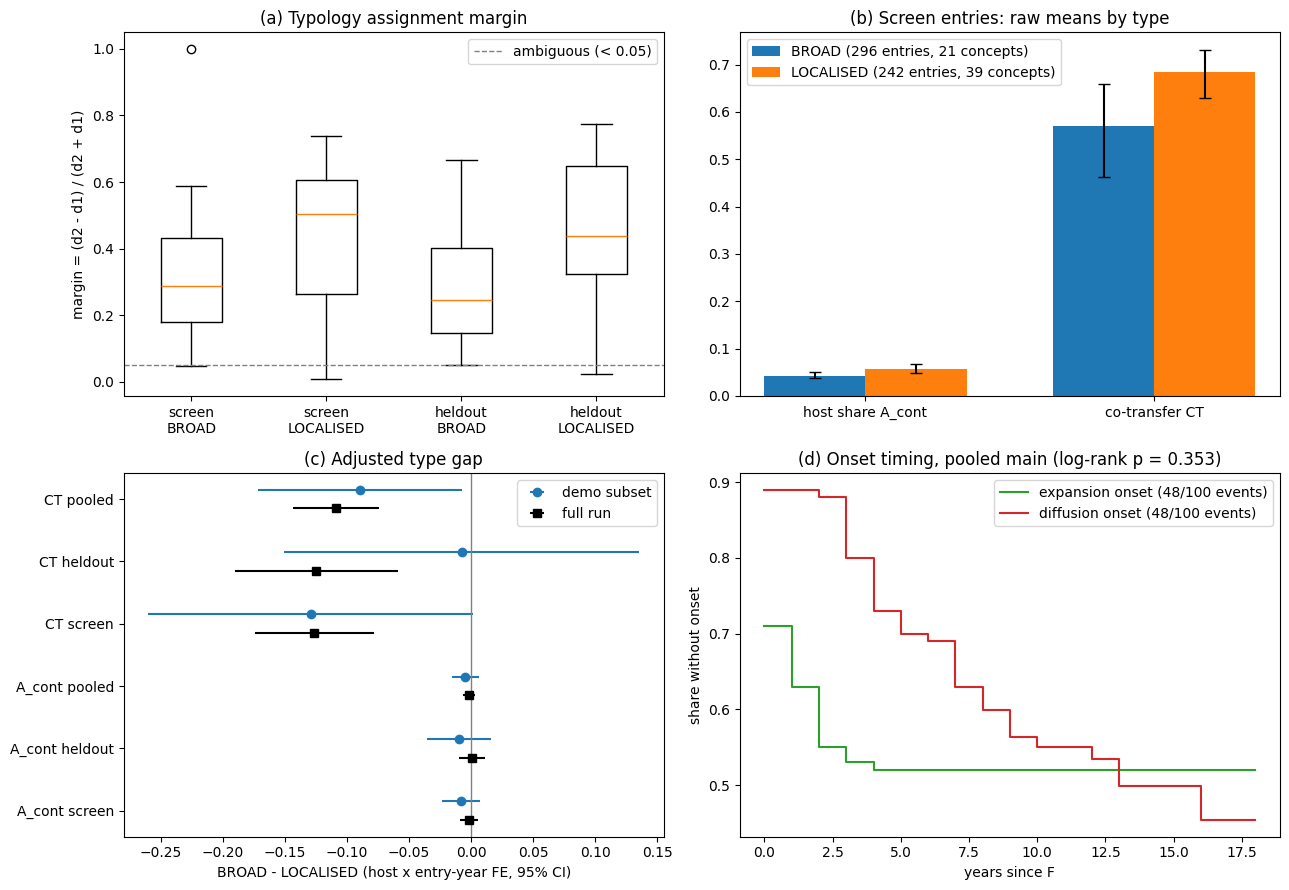

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# (a) typology margins by population and type
a = ax[0, 0]
mar = pd.concat([add_margin(typ_s).assign(population="screen"), add_margin(typ_h).assign(population="heldout")])
groups = [(p, t) for p in ("screen", "heldout") for t in (BROAD, LOCAL)]
a.boxplot([mar[(mar.population == p) & (mar.cluster_name == t)].margin for p, t in groups],
          tick_labels=[f"{p}\n{TYPE_SHORT[t]}" for p, t in groups])
a.axhline(0.05, color="grey", ls="--", lw=1, label="ambiguous (< 0.05)")
a.set_ylabel("margin = (d2 - d1) / (d2 + d1)"); a.set_title("(a) Typology assignment margin"); a.legend(loc="upper right")

# (b) raw host share and co-transfer by type (screen, cluster-bootstrap CIs)
b = ax[0, 1]
ds = root_out["screen"]["descriptives"]
labels, colors = ["A_cont_mean", "CT_mean"], {"BROAD": "#1f77b4", "LOCALISED": "#ff7f0e"}
for j, ty in enumerate(("BROAD", "LOCALISED")):
    est = [ds[ty][k]["est"] for k in labels]
    lo = [ds[ty][k]["est"] - ds[ty][k]["ci"][0] for k in labels]
    hi = [ds[ty][k]["ci"][1] - ds[ty][k]["est"] for k in labels]
    b.bar(np.arange(2) + (j - 0.5) * 0.35, est, 0.35, yerr=[lo, hi], capsize=4, color=colors[ty],
          label=f"{ty} ({ds[ty]['n_entries']} entries, {ds[ty]['n_concepts']} concepts)")
b.set_xticks(range(2)); b.set_xticklabels(["host share A_cont", "co-transfer CT"])
b.set_title("(b) Screen entries: raw means by type"); b.legend()

# (c) adjusted type gaps: demo vs full run
c = ax[1, 0]
items = [(f"{nm} {pop}", root_out[key][mdl], f"{nm2}_{pop}_adj")
         for nm, mdl, nm2 in (("A_cont", "model_i_Acont", "typegap_Acont"), ("CT", "model_ii_CT", "typegap_CT"))
         for pop, key in (("screen", "screen"), ("heldout", "heldout"), ("pooled", "pooled_W1"))]
for i, (lab, x, rk) in enumerate(items):
    c.errorbar(x["coef"], i + 0.15, xerr=[[x["coef"] - x["ci"][0]], [x["ci"][1] - x["coef"]]], fmt="o", color="#1f77b4",
               label="demo subset" if i == 0 else None)
    if rk in ref:
        c.errorbar(ref[rk], i - 0.15, xerr=[[ref[rk] - ref[rk + "_ci_lo"]], [ref[rk + "_ci_hi"] - ref[rk]]], fmt="s", color="black",
                   label="full run" if i == 0 else None)
c.axvline(0, color="grey", lw=1)
c.set_yticks(range(len(items))); c.set_yticklabels([it[0] for it in items])
c.set_xlabel("BROAD - LOCALISED (host x entry-year FE, 95% CI)"); c.set_title("(c) Adjusted type gap"); c.legend()

# (d) Kaplan-Meier: time from F to expansion vs diffusion onset (pooled main)
d = ax[1, 1]
cz = ll_out["pooled_main"]["censoring"]
for kind, col in (("expansion", "#2ca02c"), ("diffusion", "#d62728")):
    k = cz[f"km_{kind}"]
    d.step(k["timeline"], k["survival"], where="post", color=col, label=f"{kind} onset ({k['n_events']}/{k['n']} events)")
d.set_xlabel("years since F"); d.set_ylabel("share without onset")
d.set_title(f"(d) Onset timing, pooled main (log-rank p = {cz['logrank_expansion_vs_diffusion']['p']:.3g})"); d.legend()

plt.tight_layout()
plt.show()

**How to read this.**

* On the full run, BROAD concepts have many more host entries per concept, and their raw host share is slightly *lower*.
* After host × entry-year FE and RD the `A_cont` gap is null on both folds. The declared "BROAD higher host share" prediction is
  therefore not supported.
* The "BROAD lower co-transfer" prediction replicates out of sample: CT is −0.126 on the screen and −0.125 on held-out.
* The typology measures *occupancy*, and within both types host share predicts rooting.

This demo runs on 100 concepts, so check its estimates for direction and rough size against the full-run column, not for
significance. The screen and pooled CT gaps and all raw `A_cont` gaps match the full run in sign and size. The 40-concept held-out
CT gap does not: it comes out near zero, against −0.125 on all 100 held-out concepts. This shows how much a subset of this size can
move an estimate. To reproduce the full numbers, run `eval.py all` in the original workspace with the original `B` / `n_perm` values
shown in the config cell.